# 1. Import and Hardware setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset

import matplotlib.pyplot as plt

!pip install tqdm ipywidgets -q
from tqdm.auto import tqdm

import math

In [2]:
DATA_PATH = './Data'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# 2. Hyperparameter

In [3]:
MODEL_CONFIG = {
    "Lite0": (224, 0.2),
    "Lite1": (240, 0.2),
    "Lite2": (260, 0.3),
    "Lite3": (280, 0.3),
    "Lite4": (300, 0.3),
}

MODEL_NAME = 'Lite0'

IMG_SIZE, DROPOUT = MODEL_CONFIG[MODEL_NAME]

In [4]:
IN_CHANNELS = 3
BATCH_SIZE = 128
NUM_CLASSES = 101

LR = 1e-3
EPOCHS = 150
SEED = 42

# 3. Data Preparation

In [5]:
stats = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.RandomRotation(15),
    transforms.RandomCrop(IMG_SIZE),
    transforms.TrivialAugmentWide(),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(*stats),
])

test_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(*stats),
])

In [6]:
import os
import random
import numpy as np

def set_seed(seed: int = 42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [7]:
# Download training data as dummy without transforms
dummy_data = datasets.Food101(root=DATA_PATH, split="train", download=True)

# Split the dummy data into two tmp subset
train_size = int(0.8 * len(dummy_data))
val_size = len(dummy_data) - train_size
split_generator = torch.Generator().manual_seed(SEED)

train_tmp_subset, val_tmp_subset = random_split(
    dummy_data, [train_size, val_size], generator=split_generator
)

train_indices = train_tmp_subset.indices
val_indices = val_tmp_subset.indices

# Create the subsets with correct transforms
train_dataset = datasets.Food101(
    root=DATA_PATH, split="train", download=False, transform=train_transform
)
val_dataset = datasets.Food101(
    root=DATA_PATH, split="train", download=False, transform=test_transform
)

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(val_dataset, val_indices)

# Download test dataset
test_dataset = datasets.Food101(
    root=DATA_PATH, split="test", download=True, transform=test_transform
)

100%|██████████| 5.00G/5.00G [02:34<00:00, 32.3MB/s] 


In [8]:
train_generator = torch.Generator().manual_seed(SEED)
eval_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_subset, 
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
    worker_init_fn=seed_worker,
    generator=train_generator,
)

val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
    worker_init_fn=seed_worker,
    generator=eval_generator,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
    worker_init_fn=seed_worker,
    generator=eval_generator,
)

# 4. Model Architecture

In [9]:
class DropPath(nn.Module):
    def __init__(self, survival_prob: float = 0.8):
        super().__init__()
        self.survival_prob = survival_prob
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # During validation/testing or the survival probalility is 100%
        if not self.training or self.survival_prob == 1.0:
            return x
        
        # Create an empty tensor on the device like samples
        batch_size = x.shape[0]
        noise = torch.empty(batch_size, 1, 1, 1, device=x.device)
        
        # Fill the noise tensor with 1 and 0 using bernoulli
        noise.bernoulli_(self.survival_prob)
        
        # Inverted Scaling: Scale up the signal to keep the average signal
        # at 100% otherwise the model will be used to with small signal
        # and the prediction will be ruined when all connections are on.
        if self.survival_prob > 0:
            noise.div_(self.survival_prob)
        
        return x * noise


class ConvBNAct(nn.Sequential):
    def __init__(self, in_channels, out_channels, kernel_size=1, stride=1, groups=1, activation=nn.ReLU6):
        padding = (kernel_size - 1) // 2
        activation = (
                nn.Identity()
                if activation == nn.Identity
                else nn.ReLU6(inplace=True)
            )
        super().__init__(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                groups=groups,
                bias=False),
            nn.BatchNorm2d(out_channels),
            activation,
        )


class MBConv(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        expand_ratio=1,
        kernel_size=1,
        stride=1,
        survival_prob=0.8,
    ):
        super().__init__()
        hidden_channels = in_channels * expand_ratio
        self.use_res_connect = stride == 1 and in_channels==out_channels
        self.drop_path = DropPath(survival_prob) if self.use_res_connect else nn.Identity()
        
        layers = []
        
        # Expansion layer
        if expand_ratio != 1:
            layers.append(
                ConvBNAct(
                    in_channels=in_channels,
                    out_channels=hidden_channels,
                    kernel_size=1,
                    stride=1,
                    groups=1,
                    activation=nn.ReLU6,
                )
            )
        
        # Depthwise layer
        layers.append(
            ConvBNAct(
                in_channels=hidden_channels,
                out_channels=hidden_channels,
                kernel_size=kernel_size,
                stride=stride,
                groups=hidden_channels,
                activation=nn.ReLU6,
            )
        )
        
        # Projection layer
        layers.append(
            ConvBNAct(
                in_channels=hidden_channels,
                out_channels=out_channels,
                kernel_size=1,
                stride=1,
                groups=1,
                activation=nn.Identity,
            )
        )
        
        # Execute layers
        self.block = nn.Sequential(*layers)
    
    def forward(self, x):
        out = self.block(x)
        if self.use_res_connect:
            out = self.drop_path(out)
            out = x + out
        return out


class EfficientNetLite(nn.Module):
    def __init__(self, model_name, in_channels, num_classes, dropout, drop_connect_rate=0.2):
        super().__init__()
        layers = []
        
        # (exp, kernel_size, stride, out, num_layers)
        model_cfg = {
            "Lite0": {
                "config": [
                    (1, 3, 1, 16, 1),
                    (6, 3, 2, 24, 2),
                    (6, 5, 2, 40, 2),
                    (6, 3, 2, 80, 3),
                    (6, 5, 1, 112, 3),
                    (6, 5, 2, 192, 4),
                    (6, 3, 1, 320, 1),
                ],
                "first_in": 32,
            },
            "Lite1": {
                "config": [
                    (1, 3, 1, 16, 1),
                    (6, 3, 2, 24, 3),
                    (6, 5, 2, 40, 3),
                    (6, 3, 2, 80, 4),
                    (6, 5, 1, 112, 4),
                    (6, 5, 2, 192, 5),
                    (6, 3, 1, 320, 1),
                ],
                "first_in": 32,
            },
            "Lite2": {
                "config": [
                    (1, 3, 1, 16, 1),
                    (6, 3, 2, 24, 3),
                    (6, 5, 2, 48, 3),
                    (6, 3, 2, 88, 4),
                    (6, 5, 1, 120, 4),
                    (6, 5, 2, 208, 5),
                    (6, 3, 1, 352, 1),
                ],
                "first_in": 32,
            },
            "Lite3": {
                "config": [
                    (1, 3, 1, 24, 1),
                    (6, 3, 2, 32, 3),
                    (6, 5, 2, 48, 3),
                    (6, 3, 2, 96, 5),
                    (6, 5, 1, 136, 5),
                    (6, 5, 2, 232, 6),
                    (6, 3, 1, 352, 1),
                ],
                "first_in": 32,
            },
            "Lite4": {
                "config": [
                    (1, 3, 1, 24, 1),
                    (6, 3, 2, 32, 4),
                    (6, 5, 2, 56, 4),
                    (6, 3, 2, 112, 6),
                    (6, 5, 1, 160, 6),
                    (6, 5, 2, 272, 8),
                    (6, 3, 1, 352, 1),
                ],
                "first_in": 32,
            },
        }
        
        total_blocks = sum(
            math.ceil(num_layers)
            for _, _, _, _, num_layers in model_cfg[model_name]["config"]
        )
        block_id = 0
        
        # The first 3x3 conv
        out_channels = model_cfg[model_name]["first_in"]
        layers.append(
            ConvBNAct(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=3,
                stride=2,
                groups=1,
                activation=nn.ReLU6,
            )
        )
        in_channels = out_channels
        
        for exp, kernel_size, stride, out, num_layers in model_cfg[model_name]["config"]:
            for i in range(num_layers):
                stride = stride if i == 0 else 1
                survival_prob = 1.0 - drop_connect_rate * float(block_id) / total_blocks
                
                layers.append(
                    MBConv(
                        in_channels=in_channels,
                        out_channels=out,
                        kernel_size=kernel_size,
                        stride=stride,
                        expand_ratio=exp,
                        survival_prob=survival_prob,
                    )
                )
                in_channels = out
                block_id += 1

        layers.extend([
            ConvBNAct(
                in_channels=in_channels,
                out_channels=1280,
                kernel_size=1,
            ),
            nn.AdaptiveAvgPool2d(1),
        ])
        
        self.block = nn.Sequential(*layers)

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(1280, num_classes),
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.block(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

In [10]:
print(f"Using: EfficientNet{MODEL_NAME}")
model = EfficientNetLite(
    MODEL_NAME,
    IN_CHANNELS,
    NUM_CLASSES,
    DROPOUT,
).to(device)

print(f"Total parameters: {(sum(p.numel() for p in model.parameters())/1e6):.2f}M")

Using: EfficientNetLite0
Total parameters: 3.50M


# 5. Training Preparation

In [11]:
class EarlyStopping:
    def __init__(
        self, patience=10, delta=0, verbose=False, save_path="best_checkpoint.pth"
    ):
        self.patience = patience
        self.delta = delta
        self.verbose = verbose
        self.save_path = save_path
        self.verbose = verbose

        self.early_stop = False
        self.counter = 0
        self.best_loss = None
    
    def __call__(self, model, val_loss):
        # 1. For the first epoch
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        
        # 2. If the loss didnt decrease as expect
        elif val_loss >= self.best_loss - self.delta:
            self.counter += 1
            print(f"Early Stopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        
        # 3. The loss decreased properly
        else:
            self.counter = 0
            self.best_loss = val_loss
            self.save_checkpoint(model)

    def save_checkpoint(self, model):
        if self.verbose:
            print("Saving best checkpoint ...")
        state_dict = (
            model.module.state_dict()
            if hasattr(model, "module")
            else model.state_dict()
        )
        torch.save(state_dict, self.save_path)

In [12]:
def sample_cutmix_box(batch_shape, mix_ration):
    """Generate a random CutMix box for NCHW tensors
    Return: y_min, y_max, x_min, x_max
    """
    img_height = batch_shape[2]
    img_width = batch_shape[3]
    
    cutmix_scale = np.sqrt(1.0 - mix_ration)
    cut_height = int(img_height * cutmix_scale)
    cut_width = int(img_width * cutmix_scale)
    
    # Center
    cx = np.random.randint(0, img_width)
    cy = np.random.randint(0, img_height)
    
    # Calculate the box coordinates
    x_min = np.clip(cx - cut_width // 2, 0, img_width)
    x_max = np.clip(cx + cut_width // 2, 0, img_width)
    y_min = np.clip(cy - cut_height // 2, 0, img_height)
    y_max = np.clip(cy + cut_height // 2, 0, img_height)
    
    return y_min, y_max, x_min, x_max

def apply_mixup_cutmix(x, y, p=0.5, alpha=1.0, cutmix_prob=0.5):
    """Returns:
        - x_mixed: The augmented image data 
        - y_a: The original labels of the current batch
        - y_b: The shuffled labels
        - lam: The mixing coefficient
        - use_mix: True or False
    """
    use_mix = np.random.rand() < p
    
    # 1. Not using mix
    if not use_mix:
        return x, y, y, 1.0, False
    
    # 2. Using mix
    # Create the mixing coefficient
    lam = float(np.random.beta(alpha, alpha))
    
    # Create a shuffled list of indices to decide which images
    # in the batch will be mixed together
    rand_index = torch.randperm(x.size(0), device=x.device)
    y_a, y_b = y, y[rand_index]
    
    # CutMix
    if np.random.rand() < cutmix_prob:
        x = x.clone()
        
        # Get the box coordinates
        y_min, y_max, x_min, x_max = sample_cutmix_box(x.size(), lam)
        
        # Put the other image in the box
        x[:, :, y_min:y_max, x_min:x_max] = x[rand_index, :, y_min:y_max, x_min:x_max]
        
        # Recalculate new lamda coefficient
        lam = 1.0 - ((y_max - y_min) * (x_max - x_min) / (x.size(-2) * x.size(-1)))
    # MixUp
    else:
        x = lam * x + (1.0 - lam) * x[rand_index, :]
    return x, y_a, y_b, lam, True

In [13]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.05)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer=optimizer,
    max_lr=LR,
    epochs=EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.1,
    div_factor=10,
    final_div_factor=100,
)

# Scaler for using AMP - Mixed Precision
scaler = torch.amp.GradScaler(device)

In [14]:
def train(model, loader, criterion, optimizer, scaler, scheduler):
    model.train()
    train_loss, train_acc = 0.0, 0.0
    loop = tqdm(loader, desc="Training", leave=False)

    for x, y in loop:
        # Move samples and labels to device
        x, y = x.to(device), y.to(device)

        # Zero out the gradients of last batch
        optimizer.zero_grad(set_to_none=True)

        # Using CutMix/MixUp
        x, y_a, y_b, lam, use_mix = apply_mixup_cutmix(
            x, y, p=0.5, alpha=1.0, cutmix_prob=0.5
        )

        with torch.amp.autocast(device_type=device.type):
            # Get prediction
            out = model(x)

            # Get the loss
            loss = (
                lam * criterion(out, y_a) + (1 - lam) * criterion(out, y_b)
                if use_mix
                else criterion(out, y)
            )

        # Scale up the loss and backpropagate
        scaler.scale(loss).backward()

        # Unscale and clip the gradients
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Update the paramters
        scaler.step(optimizer)

        # Update the scaler
        scaler.update()

        # Update lr after each batch because of using OneCycleLR
        scheduler.step()

        train_loss += loss.detach() * x.size(0)
        if use_mix:
            train_acc += (
                lam * (out.argmax(1) == y_a).float()
                + (1 - lam) * (out.argmax(1) == y_b).float()
            ).sum()
        else:
            train_acc += (out.argmax(1) == y).sum()
    return train_loss.item() / len(loader.dataset), train_acc.item() / len(
        loader.dataset
    )


def validate(model, loader, criterion):
    model.eval()
    val_loss, val_acc = 0.0, 0.0
    loop = tqdm(loader, desc="Validation", leave=False)

    with torch.no_grad():
        for x, y in loop:
            x, y = x.to(device), y.to(device)
            with torch.amp.autocast(device_type=device.type):
                out = model(x)
                loss = criterion(out, y)
            val_loss += loss.detach() * x.size(0)
            val_acc += (out.argmax(1) == y).sum()
    return val_loss.item() / len(loader.dataset), val_acc.item() / len(loader.dataset)


def test(model, loader):
    model.eval()
    test_acc = 0.0
    loop = tqdm(loader, desc="Testing", leave=False)

    with torch.no_grad():
        for x, y in loop:
            x, y = x.to(device), y.to(device)
            out = model(x)
            test_acc += (out.argmax(1) == y).sum()
    return test_acc / len(loader.dataset)

# 6. Train

In [15]:
train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
early_stopping = EarlyStopping(patience=10, delta=0.01)

for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, scaler, scheduler)
    val_loss, val_acc = validate(model, val_loader, criterion)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    
    print(f"Epoch {epoch+1}/{EPOCHS}: train_loss: {train_loss:.4f}, val_loss: {val_loss:.4f}, " +
          f"train_acc: {train_acc:.4f}, val_acc: {val_acc:.4f}")
    
    early_stopping(model, val_loss)
    if early_stopping.early_stop:
        print("Early Stopping")
        break

best_model = model.module if hasattr(model, 'module') else model
best_model.load_state_dict(torch.load('best_checkpoint.pth', map_location=device))
test_acc = test(model, test_loader)
print(f"Final test accuracy: {test_acc:.4f}")

Training:   0%|          | 0/474 [00:00<?, ?it/s]

Validation:   0%|          | 0/119 [00:00<?, ?it/s]

Epoch 1/150: train_loss: 4.5998, val_loss: 4.4538, train_acc: 0.0151, val_acc: 0.0335


Training:   0%|          | 0/474 [00:00<?, ?it/s]

Validation:   0%|          | 0/119 [00:00<?, ?it/s]

...

Training:   0%|          | 0/474 [00:00<?, ?it/s]

Validation:   0%|          | 0/119 [00:00<?, ?it/s]

Epoch 70/150: train_loss: 2.1852, val_loss: 1.7240, train_acc: 0.6321, val_acc: 0.7294
Early Stopping counter: 10 out of 10
Early Stopping


Testing:   0%|          | 0/198 [00:00<?, ?it/s]

Final test accuracy: 0.7830


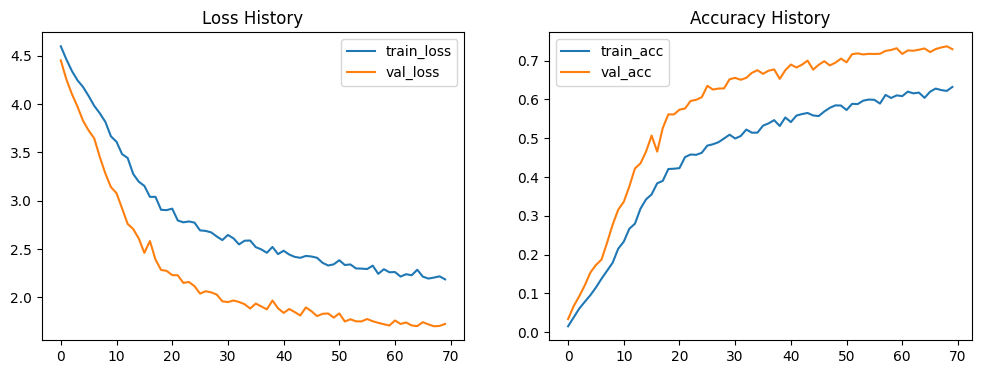

In [16]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='train_loss')
plt.plot(val_losses, label='val_loss')
plt.title('Loss History')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='train_acc')
plt.plot(val_accuracies, label='val_acc')
plt.title('Accuracy History')
plt.legend()

# 7. GradCAM

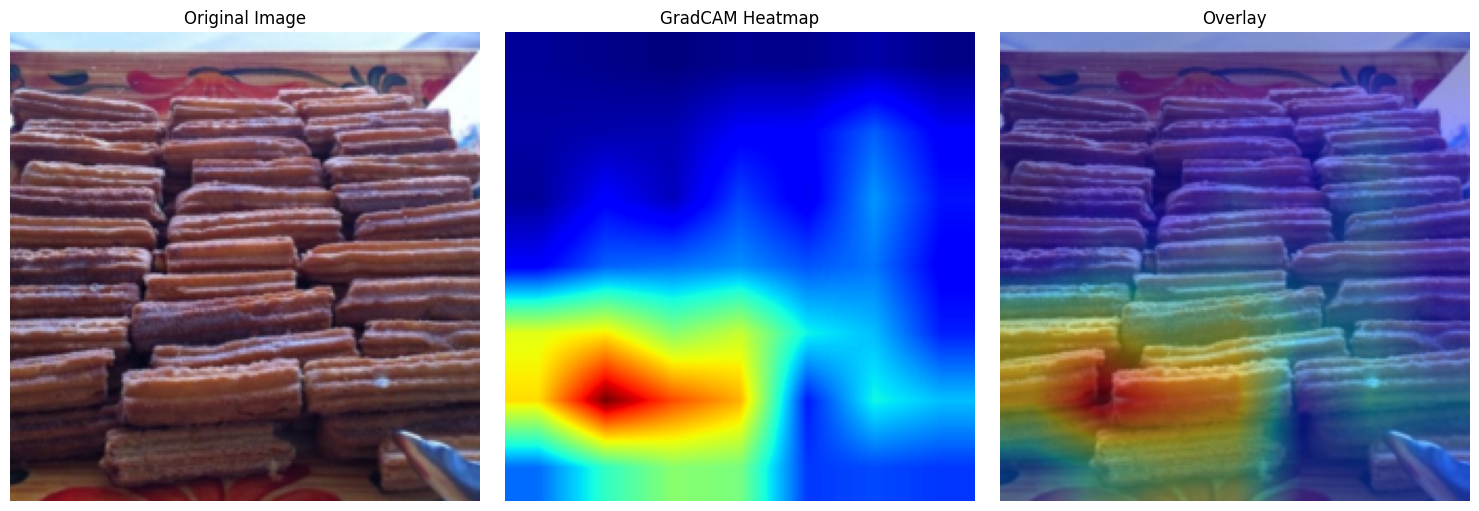

In [17]:
import torch.nn.functional as F

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_heatmap(self, input_image, target_class=None):
        self.model.eval()

        model_output = self.model(input_image)

        if target_class is None:
            target_class = model_output.argmax(dim=1).item()

        self.model.zero_grad()
        target_score = model_output[0, target_class]
        target_score.backward()

        weights = torch.mean(self.gradients, dim=[2, 3], keepdim=True)
        cam = torch.sum(weights * self.activations, dim=1, keepdim=True)
        cam = F.relu(cam)

        cam = F.interpolate(
            cam,
            size=(input_image.shape[2], input_image.shape[3]),
            mode="bilinear",
            align_corners=False,
        )

        cam = cam.squeeze().cpu().detach().numpy()
        cam = cam - np.min(cam)
        cam = cam / (np.max(cam) + 1e-8)
        return cam

def plot_gradcam(image_tensor, cam_heatmap):
    img = image_tensor.squeeze().cpu().numpy().transpose(1, 2, 0)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)

    jet = plt.get_cmap("jet")
    heatmap_colored = jet(cam_heatmap)[..., :3]
    overlay = heatmap_colored * 0.4 + img * 0.6
    overlay = np.clip(overlay, 0, 1)

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(img)
    ax[0].set_title("Original Image")
    ax[0].axis("off")

    ax[1].imshow(cam_heatmap, cmap="jet")
    ax[1].set_title("GradCAM Heatmap")
    ax[1].axis("off")

    ax[2].imshow(overlay)
    ax[2].set_title("Overlay")
    ax[2].axis("off")

    plt.tight_layout()
    plt.show()

target_layer = model.block[-2]

grad_cam = GradCAM(model, target_layer)

sample_images, sample_labels = next(iter(test_loader))
sample_image = sample_images[0:1].to(device)

heatmap = grad_cam.generate_heatmap(sample_image)
plot_gradcam(sample_image, heatmap)
